In [28]:
# Cell 1 — Setup & Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import warnings

warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.labelsize'] = 11

pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.2f}'.format)

print('Libraries loaded.')

df = pd.read_csv('WA_Fn-UseC_-HR-Employee-Attrition.csv')
df.head()

Libraries loaded.


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,Over18,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,2,Female,94,3,2,Sales Executive,4,Single,5993,19479,8,Y,Yes,11,3,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,3,Male,61,2,2,Research Scientist,2,Married,5130,24907,1,Y,No,23,4,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,4,Male,92,2,1,Laboratory Technician,3,Single,2090,2396,6,Y,Yes,15,3,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,4,Female,56,3,1,Research Scientist,3,Married,2909,23159,1,Y,Yes,11,3,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,1,Male,40,3,1,Laboratory Technician,2,Married,3468,16632,9,Y,No,12,3,4,80,1,6,3,3,2,2,2,2


In [29]:
# Cell 2 — Dataset Overview
print('=== SHAPE ===')
print(f'Rows: {df.shape[0]:,}  |  Columns: {df.shape[1]}')

print('\n=== DATA TYPES ===')
print(df.dtypes.value_counts())

print('\n=== MISSING VALUES ===')
missing = df.isnull().sum()
print(missing[missing > 0] if missing.any() else 'No missing values found.')

print('\n=== DUPLICATE ROWS ===')
print(f'Duplicates: {df.duplicated().sum()}')

print('\n=== ALL COLUMNS & TYPES ===')
print(df.dtypes.to_string())


=== SHAPE ===
Rows: 1,470  |  Columns: 35

=== DATA TYPES ===
int64     26
object     9
Name: count, dtype: int64

=== MISSING VALUES ===
No missing values found.

=== DUPLICATE ROWS ===
Duplicates: 0

=== ALL COLUMNS & TYPES ===
Age                          int64
Attrition                   object
BusinessTravel              object
DailyRate                    int64
Department                  object
DistanceFromHome             int64
Education                    int64
EducationField              object
EmployeeCount                int64
EmployeeNumber               int64
EnvironmentSatisfaction      int64
Gender                      object
HourlyRate                   int64
JobInvolvement               int64
JobLevel                     int64
JobRole                     object
JobSatisfaction              int64
MaritalStatus               object
MonthlyIncome                int64
MonthlyRate                  int64
NumCompaniesWorked           int64
Over18                      object


In [30]:
# Numerical descriptive statistics
df.describe().T.style.background_gradient(cmap='Blues', subset=['mean', 'std'])


,count,mean,std,min,25%,50%,75%,max
Age,1470.000000,36.923810,9.135373,18.000000,30.000000,36.000000,43.000000,60.000000
DailyRate,1470.000000,802.485714,403.509100,102.000000,465.000000,802.000000,1157.000000,1499.000000
DistanceFromHome,1470.000000,9.192517,8.106864,1.000000,2.000000,7.000000,14.000000,29.000000
Education,1470.000000,2.912925,1.024165,1.000000,2.000000,3.000000,4.000000,5.000000
EmployeeCount,1470.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000
EmployeeNumber,1470.000000,1024.865306,602.024335,1.000000,491.250000,1020.500000,1555.750000,2068.000000
EnvironmentSatisfaction,1470.000000,2.721769,1.093082,1.000000,2.000000,3.000000,4.000000,4.000000
HourlyRate,1470.000000,65.891156,20.329428,30.000000,48.000000,66.000000,83.750000,100.000000
JobInvolvement,1470.000000,2.729932,0.711561,1.000000,2.000000,3.000000,3.000000,4.000000
JobLevel,1470.000000,2.063946,1.106940,1.000000,1.000000,2.000000,3.000000,5.000000


In [31]:
# Categorical descriptive statistics
df.describe(include='object').T


,count,unique,top,freq
Attrition,1470,2,No,1233
BusinessTravel,1470,3,Travel_Rarely,1043
Department,1470,3,Research & Development,961
EducationField,1470,6,Life Sciences,606
Gender,1470,2,Male,882
JobRole,1470,9,Sales Executive,326
MaritalStatus,1470,3,Married,673
Over18,1470,1,Y,1470
OverTime,1470,2,No,1054


In [32]:
# Cell 3 — Drop Constant/ID Columns
cols_to_drop = ['EmployeeCount', 'EmployeeNumber', 'Over18', 'StandardHours']
df.drop(columns=cols_to_drop, inplace=True)

print(f'Dropped: {cols_to_drop}')
print(f'Remaining shape: {df.shape}')
print(f'Remaining columns ({df.shape[1]}):')
print(df.columns.tolist())


Dropped: ['EmployeeCount', 'EmployeeNumber', 'Over18', 'StandardHours']
Remaining shape: (1470, 31)
Remaining columns (31):
['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department', 'DistanceFromHome', 'Education', 'EducationField', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction', 'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'OverTime', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']


           Count  Percentage
Attrition                   
No          1233       83.88
Yes          237       16.12


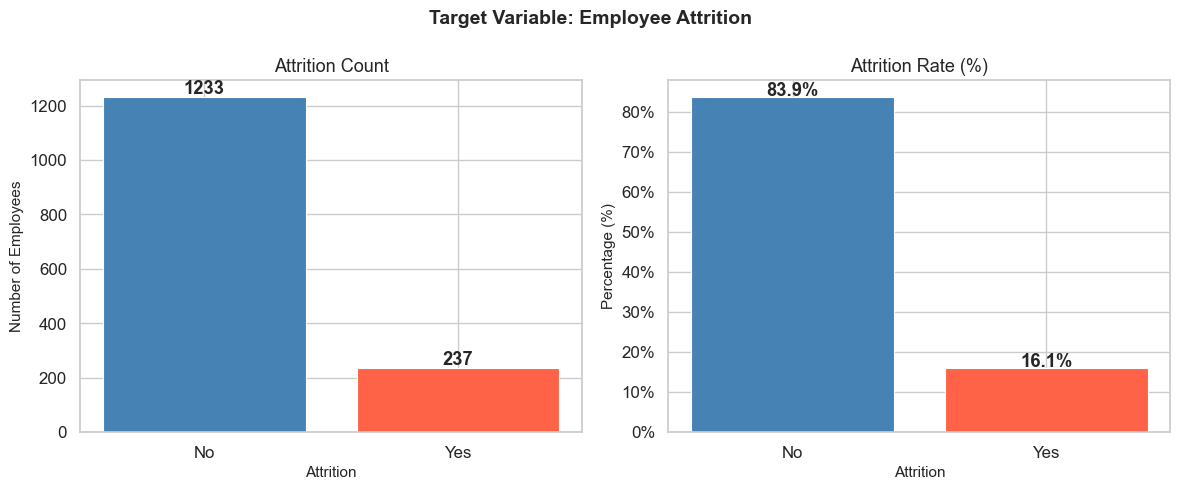

In [33]:
# Cell 4 — Target Variable Analysis
attrition_counts = df['Attrition'].value_counts()
attrition_pct = df['Attrition'].value_counts(normalize=True) * 100

summary = pd.DataFrame({'Count': attrition_counts, 'Percentage': attrition_pct.round(2)})
print(summary)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].bar(attrition_counts.index, attrition_counts.values,
            color=['steelblue', 'tomato'], edgecolor='white', linewidth=0.8)
axes[0].set_title('Attrition Count')
axes[0].set_xlabel('Attrition')
axes[0].set_ylabel('Number of Employees')
for i, v in enumerate(attrition_counts.values):
    axes[0].text(i, v + 10, str(v), ha='center', fontweight='bold')

axes[1].bar(attrition_pct.index, attrition_pct.values,
            color=['steelblue', 'tomato'], edgecolor='white', linewidth=0.8)
axes[1].set_title('Attrition Rate (%)')
axes[1].set_xlabel('Attrition')
axes[1].set_ylabel('Percentage (%)')
axes[1].yaxis.set_major_formatter(mticker.PercentFormatter())
for i, v in enumerate(attrition_pct.values):
    axes[1].text(i, v + 0.3, f'{v:.1f}%', ha='center', fontweight='bold')

plt.suptitle('Target Variable: Employee Attrition', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


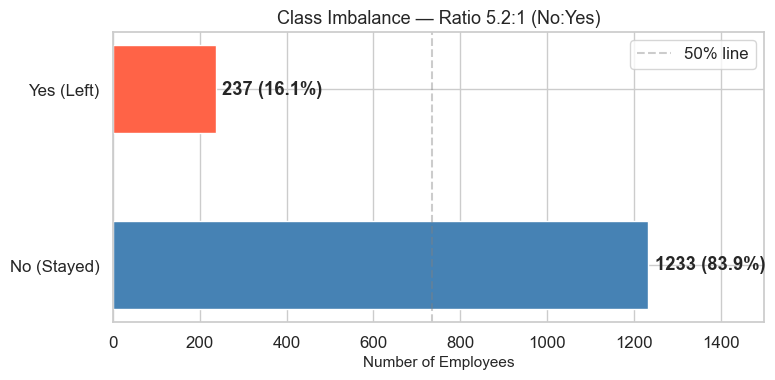

Imbalance ratio: 5.2:1
A model predicting "No" always achieves ~84% accuracy — recall for "Yes" is the priority metric.


In [34]:
# Cell 5 — Class Imbalance Framing
imbalance_ratio = attrition_counts['No'] / attrition_counts['Yes']

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.barh(['No (Stayed)', 'Yes (Left)'],
               [attrition_counts['No'], attrition_counts['Yes']],
               color=['steelblue', 'tomato'], height=0.5)

for bar, count in zip(bars, [attrition_counts['No'], attrition_counts['Yes']]):
    ax.text(bar.get_width() + 15, bar.get_y() + bar.get_height() / 2,
            f'{count} ({count / df.shape[0] * 100:.1f}%)', va='center', fontweight='bold')

ax.set_xlabel('Number of Employees')
ax.set_title(f'Class Imbalance — Ratio {imbalance_ratio:.1f}:1 (No:Yes)')
ax.set_xlim(0, 1500)
ax.axvline(x=df.shape[0] * 0.5, color='gray', linestyle='--', alpha=0.4, label='50% line')
ax.legend()
plt.tight_layout()
plt.show()

print(f'Imbalance ratio: {imbalance_ratio:.1f}:1')
print('A model predicting "No" always achieves ~84% accuracy — recall for "Yes" is the priority metric.')


Numerical columns (23): ['Age', 'DailyRate', 'DistanceFromHome', 'Education', 'EnvironmentSatisfaction', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']


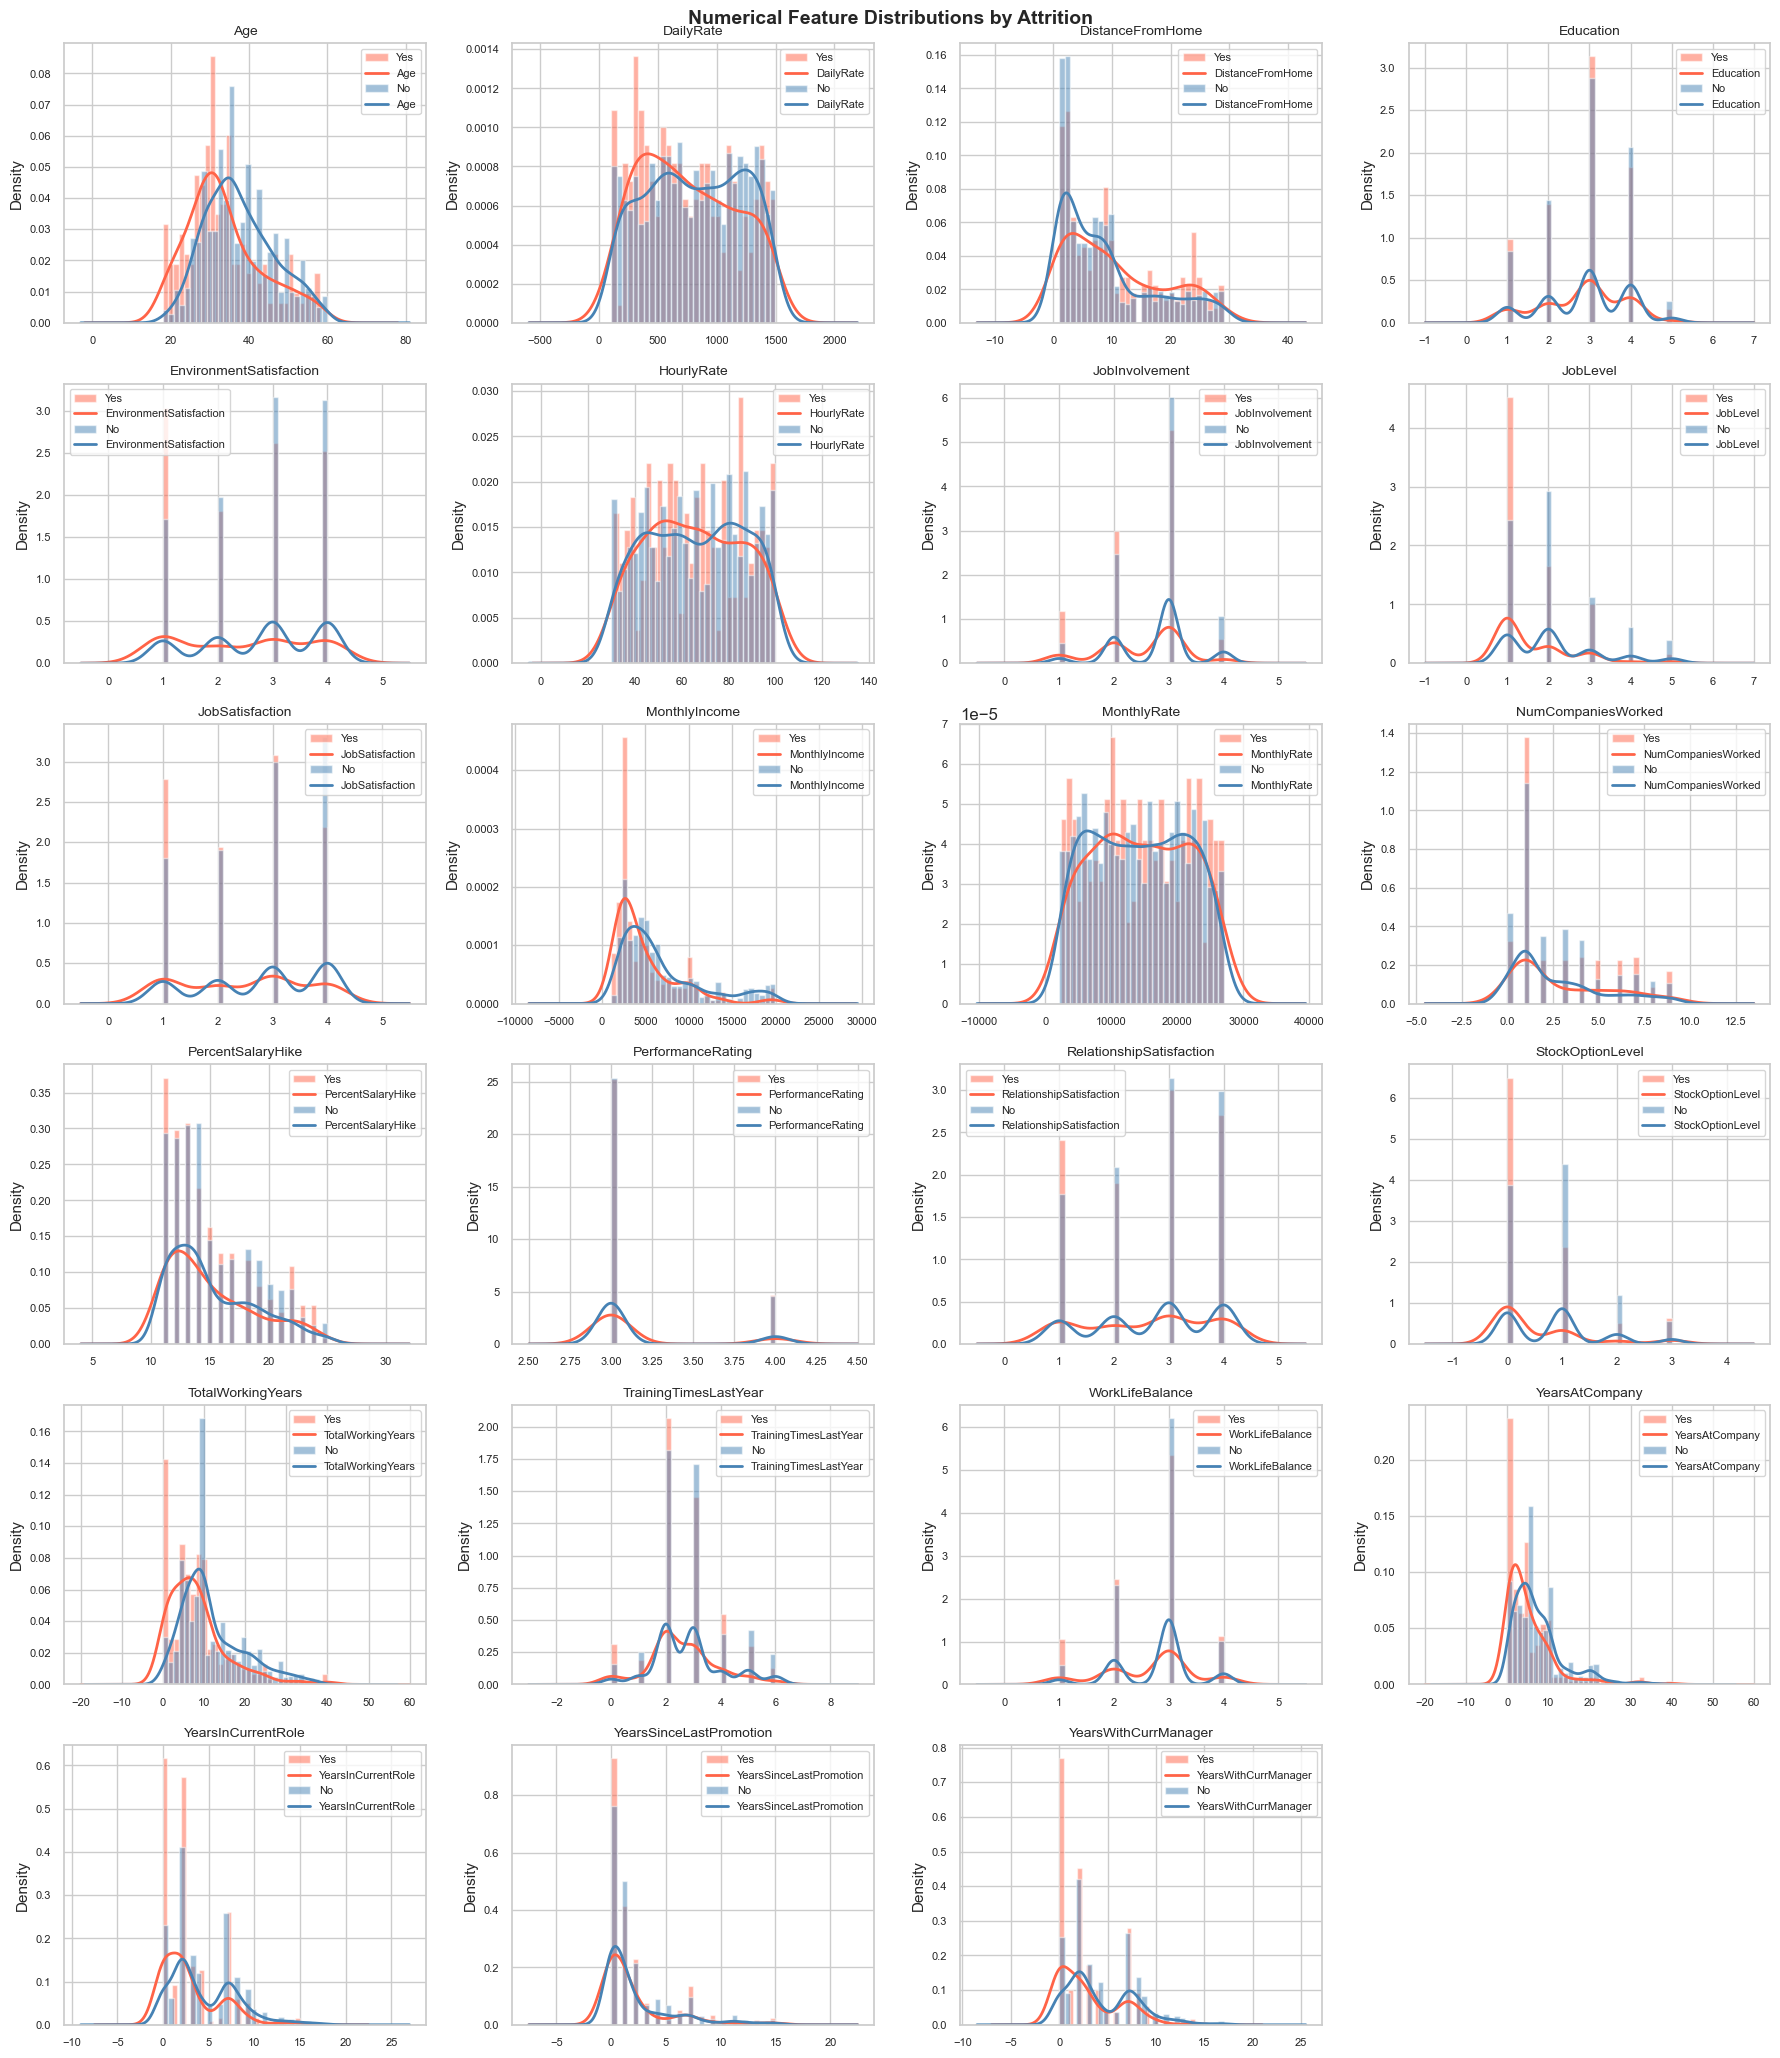

In [35]:
# Cell 6 — Numerical Feature Distributions by Attrition
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
print(f'Numerical columns ({len(numerical_cols)}): {numerical_cols}')

n_cols = 4
n_rows = (len(numerical_cols) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 3.5))
axes = axes.flatten()

palette = {'Yes': 'tomato', 'No': 'steelblue'}

for i, col in enumerate(numerical_cols):
    for attrition_val, color in palette.items():
        subset = df[df['Attrition'] == attrition_val][col]
        axes[i].hist(subset, bins=30, alpha=0.5, color=color,
                     label=attrition_val, density=True)
        subset.plot.kde(ax=axes[i], color=color, linewidth=2)
    axes[i].set_title(col, fontsize=10)
    axes[i].set_xlabel('')
    axes[i].legend(fontsize=8)
    axes[i].tick_params(labelsize=8)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Numerical Feature Distributions by Attrition', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


Categorical columns: ['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'OverTime']


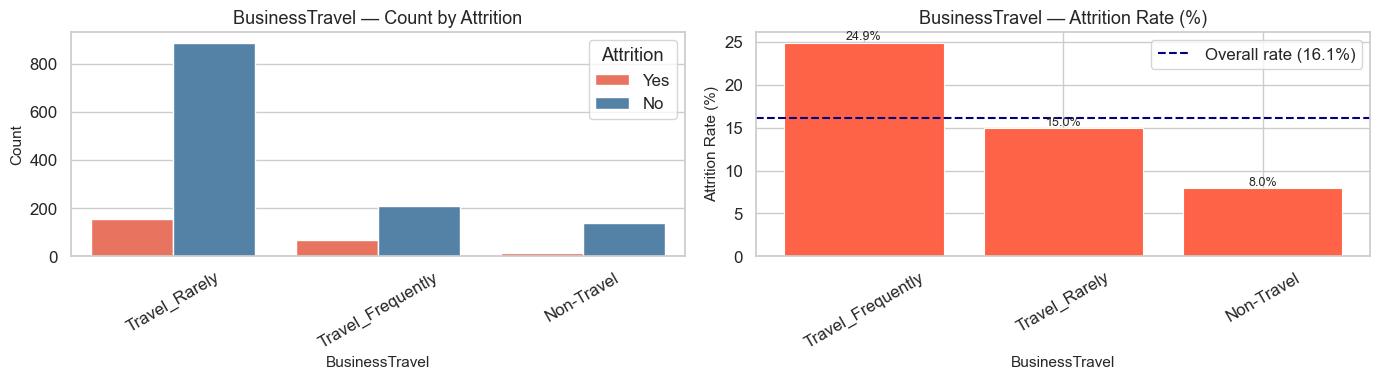

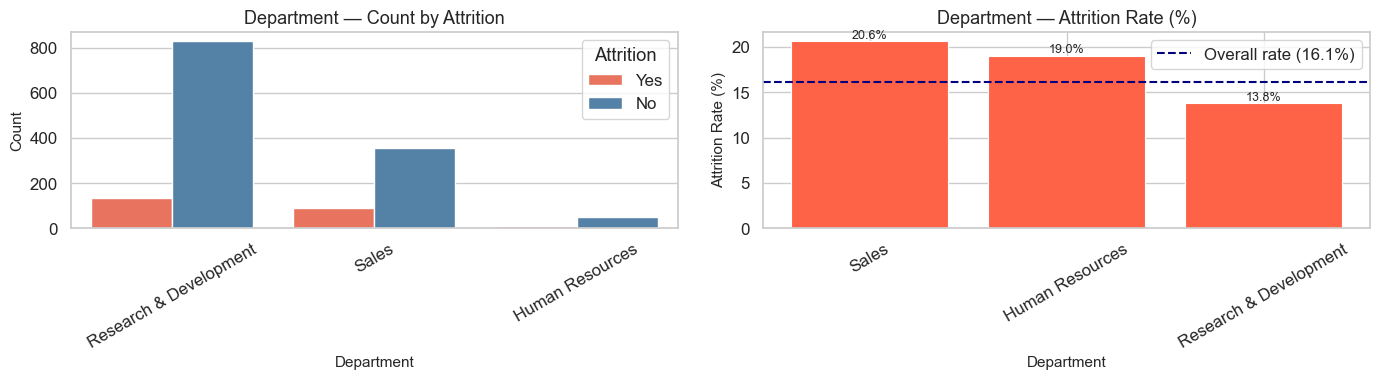

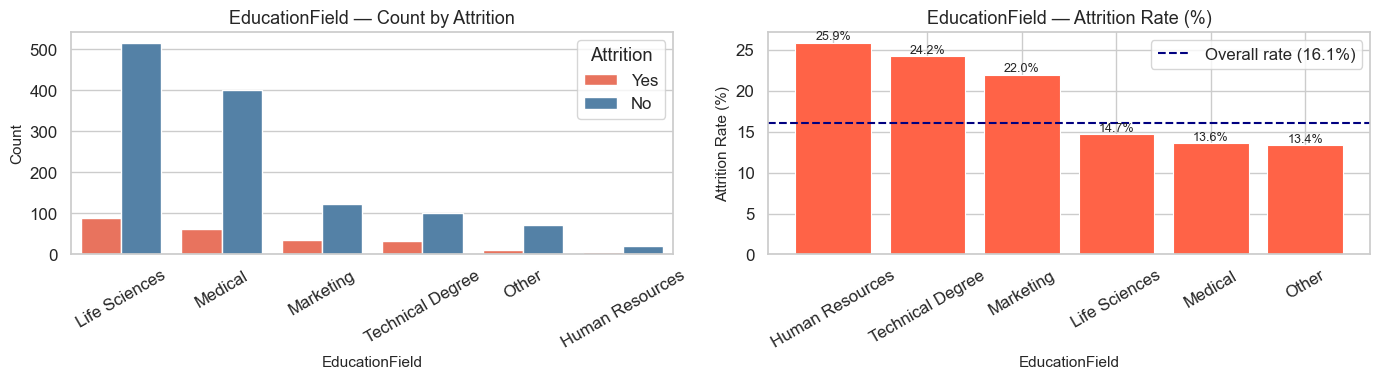

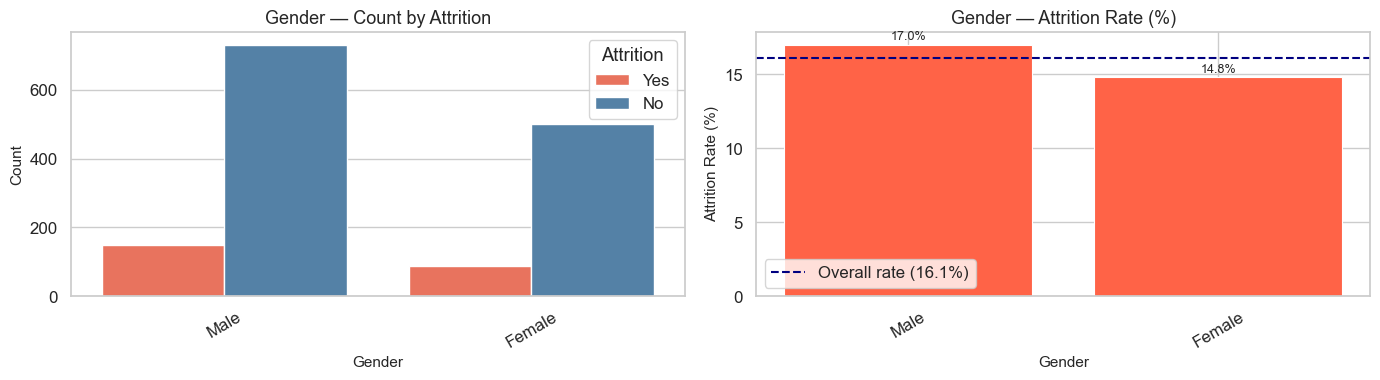

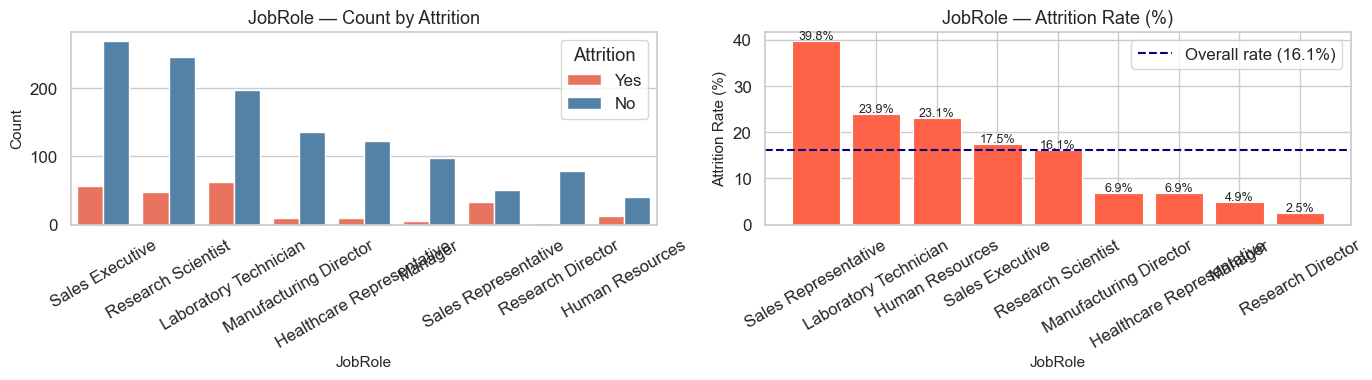

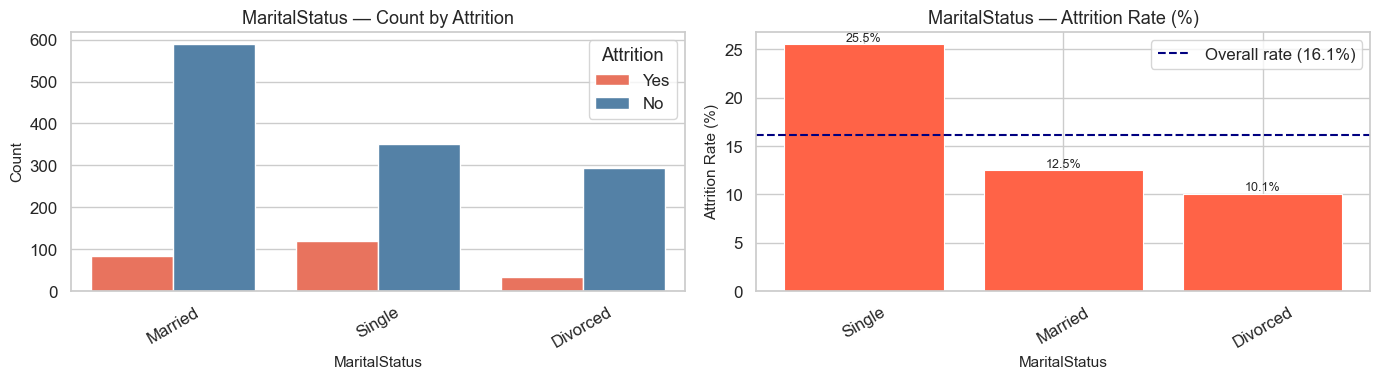

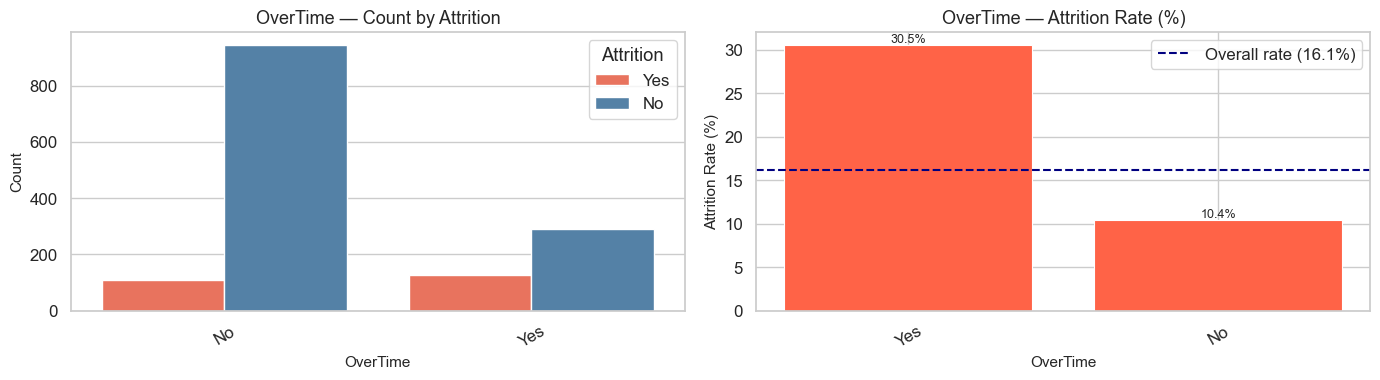

In [36]:
# Cell 7 — Categorical Feature Breakdown by Attrition
categorical_cols = df.select_dtypes(include='object').columns.tolist()
categorical_cols = [c for c in categorical_cols if c != 'Attrition']
print(f'Categorical columns: {categorical_cols}')

overall_rate = (df['Attrition'] == 'Yes').mean() * 100

for col in categorical_cols:
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))

    sns.countplot(data=df, x=col, hue='Attrition', ax=axes[0],
                  palette={'Yes': 'tomato', 'No': 'steelblue'},
                  order=df[col].value_counts().index)
    axes[0].set_title(f'{col} — Count by Attrition')
    axes[0].set_xlabel(col)
    axes[0].set_ylabel('Count')
    axes[0].tick_params(axis='x', rotation=30)
    axes[0].legend(title='Attrition')

    rate = df.groupby(col)['Attrition'].apply(
        lambda x: (x == 'Yes').sum() / len(x) * 100
    ).reset_index()
    rate.columns = [col, 'AttritionRate']
    rate = rate.sort_values('AttritionRate', ascending=False)

    bars = axes[1].bar(rate[col], rate['AttritionRate'],
                       color='tomato', edgecolor='white', linewidth=0.8)
    axes[1].axhline(y=overall_rate, color='navy', linestyle='--',
                    linewidth=1.5, label=f'Overall rate ({overall_rate:.1f}%)')
    axes[1].set_title(f'{col} — Attrition Rate (%)')
    axes[1].set_xlabel(col)
    axes[1].set_ylabel('Attrition Rate (%)')
    axes[1].tick_params(axis='x', rotation=30)
    axes[1].legend()
    for bar, val in zip(bars, rate['AttritionRate']):
        axes[1].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
                     f'{val:.1f}%', ha='center', fontsize=9)

    plt.tight_layout()
    plt.show()


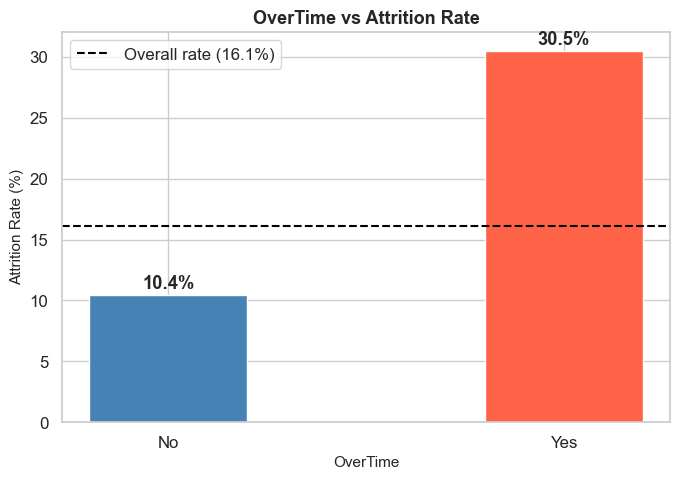

In [37]:
# Cell 8a — OverTime vs Attrition
overall_rate = (df['Attrition'] == 'Yes').mean() * 100

ot_rate = df.groupby('OverTime')['Attrition'].apply(
    lambda x: (x == 'Yes').mean() * 100).reset_index()
ot_rate.columns = ['OverTime', 'AttritionRate']

fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(ot_rate['OverTime'], ot_rate['AttritionRate'],
              color=['steelblue', 'tomato'], width=0.4, edgecolor='white')
ax.axhline(y=overall_rate, color='black', linestyle='--', label=f'Overall rate ({overall_rate:.1f}%)')
for bar, val in zip(bars, ot_rate['AttritionRate']):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
            f'{val:.1f}%', ha='center', fontweight='bold')
ax.set_title('OverTime vs Attrition Rate', fontweight='bold')
ax.set_ylabel('Attrition Rate (%)')
ax.set_xlabel('OverTime')
ax.legend()
plt.tight_layout()
plt.show()


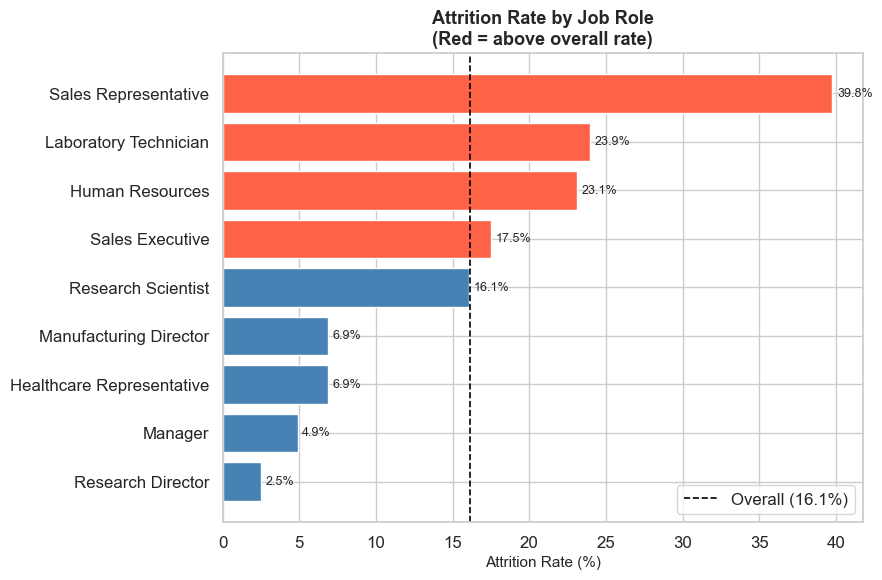

In [38]:
# Cell 8b — JobRole vs Attrition (horizontal bar)
jobrole_rate = df.groupby('JobRole')['Attrition'].apply(
    lambda x: (x == 'Yes').mean() * 100).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(9, 6))
colors = ['tomato' if v > overall_rate else 'steelblue' for v in jobrole_rate.values]
ax.barh(jobrole_rate.index, jobrole_rate.values, color=colors, edgecolor='white')
ax.axvline(x=overall_rate, color='black', linestyle='--', linewidth=1.2,
           label=f'Overall ({overall_rate:.1f}%)')
for i, val in enumerate(jobrole_rate.values):
    ax.text(val + 0.3, i, f'{val:.1f}%', va='center', fontsize=9)
ax.set_xlabel('Attrition Rate (%)')
ax.set_title('Attrition Rate by Job Role\n(Red = above overall rate)', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()


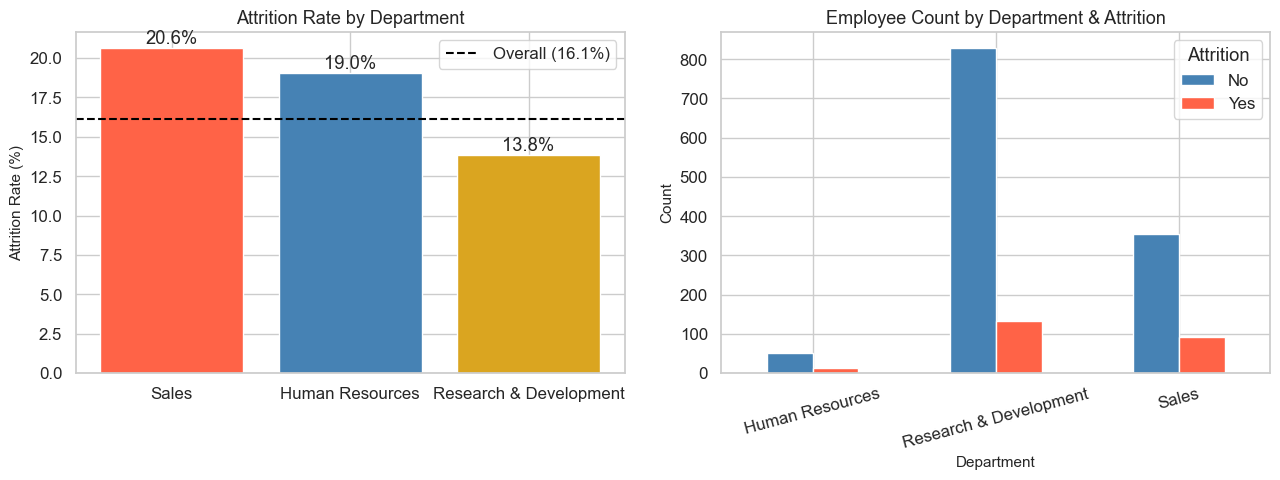

In [39]:
# Cell 8c — Department vs Attrition
dept_rate = df.groupby('Department')['Attrition'].apply(
    lambda x: (x == 'Yes').mean() * 100).sort_values(ascending=False).reset_index()
dept_rate.columns = ['Department', 'AttritionRate']

dept_counts = df.groupby(['Department', 'Attrition']).size().unstack(fill_value=0)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].bar(dept_rate['Department'], dept_rate['AttritionRate'],
            color=['tomato', 'steelblue', 'goldenrod'], edgecolor='white')
axes[0].axhline(y=overall_rate, color='black', linestyle='--',
                label=f'Overall ({overall_rate:.1f}%)')
axes[0].set_title('Attrition Rate by Department')
axes[0].set_ylabel('Attrition Rate (%)')
axes[0].legend()
for i, row in enumerate(dept_rate.itertuples()):
    axes[0].text(i, row.AttritionRate + 0.3, f'{row.AttritionRate:.1f}%', ha='center')

dept_counts.plot(kind='bar', ax=axes[1], color=['steelblue', 'tomato'], edgecolor='white')
axes[1].set_title('Employee Count by Department & Attrition')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=15)
axes[1].legend(title='Attrition')
plt.tight_layout()
plt.show()


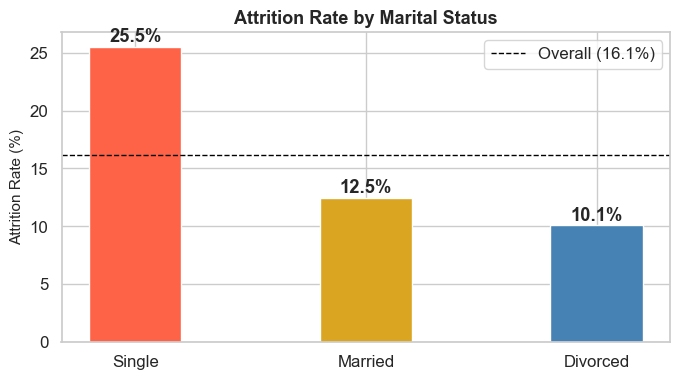

In [40]:
# Cell 8d — MaritalStatus vs Attrition
ms_rate = df.groupby('MaritalStatus')['Attrition'].apply(
    lambda x: (x == 'Yes').mean() * 100).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(ms_rate.index, ms_rate.values,
       color=['tomato', 'goldenrod', 'steelblue'], edgecolor='white', width=0.4)
ax.axhline(y=overall_rate, color='black', linestyle='--',
           linewidth=1, label=f'Overall ({overall_rate:.1f}%)')
for i, val in enumerate(ms_rate.values):
    ax.text(i, val + 0.4, f'{val:.1f}%', ha='center', fontweight='bold')
ax.set_title('Attrition Rate by Marital Status', fontweight='bold')
ax.set_ylabel('Attrition Rate (%)')
ax.legend()
plt.tight_layout()
plt.show()


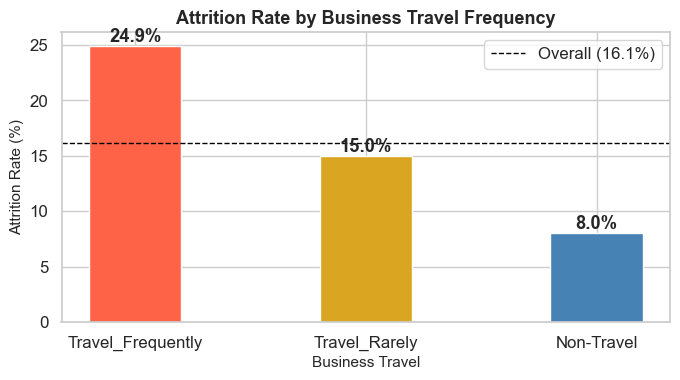

In [41]:
# Cell 8e — BusinessTravel vs Attrition
bt_rate = df.groupby('BusinessTravel')['Attrition'].apply(
    lambda x: (x == 'Yes').mean() * 100).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(bt_rate.index, bt_rate.values,
       color=['tomato', 'goldenrod', 'steelblue'], edgecolor='white', width=0.4)
ax.axhline(y=overall_rate, color='black', linestyle='--',
           linewidth=1, label=f'Overall ({overall_rate:.1f}%)')
for i, val in enumerate(bt_rate.values):
    ax.text(i, val + 0.4, f'{val:.1f}%', ha='center', fontweight='bold')
ax.set_title('Attrition Rate by Business Travel Frequency', fontweight='bold')
ax.set_ylabel('Attrition Rate (%)')
ax.set_xlabel('Business Travel')
ax.legend()
plt.tight_layout()
plt.show()


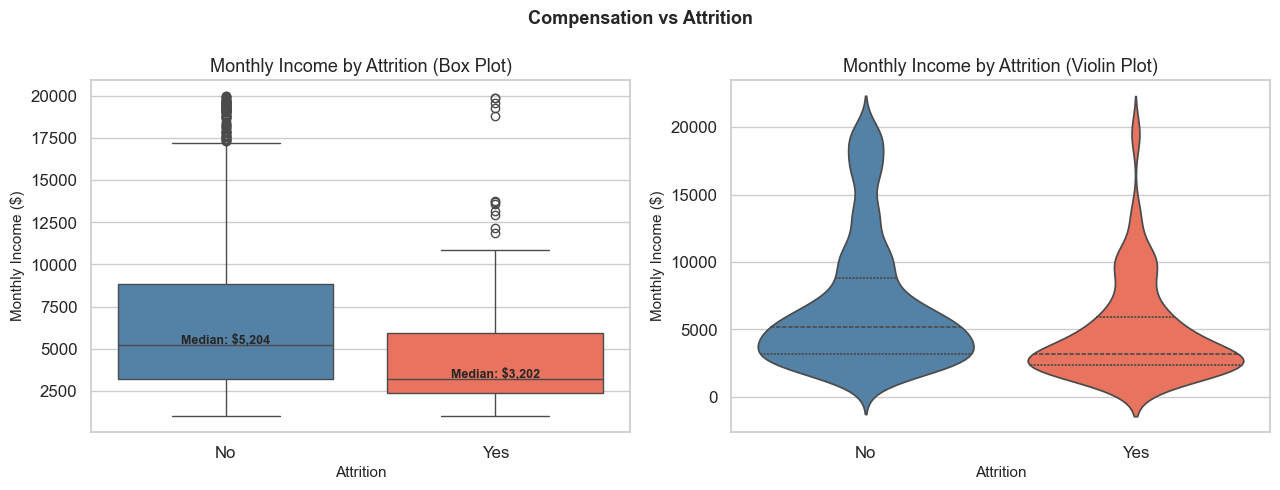

            count    mean     std     min     25%     50%     75%      max
Attrition                                                                 
No        1233.00 6833.00 4818.00 1051.00 3211.00 5204.00 8834.00 19999.00
Yes        237.00 4787.00 3640.00 1009.00 2373.00 3202.00 5916.00 19859.00


In [42]:
# Cell 9 — Compensation Analysis
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.boxplot(data=df, x='Attrition', y='MonthlyIncome', ax=axes[0],
            palette={'Yes': 'tomato', 'No': 'steelblue'}, order=['No', 'Yes'])
axes[0].set_title('Monthly Income by Attrition (Box Plot)')
axes[0].set_ylabel('Monthly Income ($)')
for i, group in enumerate(['No', 'Yes']):
    median = df[df['Attrition'] == group]['MonthlyIncome'].median()
    axes[0].text(i, median + 100, f'Median: ${median:,.0f}',
                 ha='center', fontsize=9, fontweight='bold')

sns.violinplot(data=df, x='Attrition', y='MonthlyIncome', ax=axes[1],
               palette={'Yes': 'tomato', 'No': 'steelblue'},
               order=['No', 'Yes'], inner='quartile')
axes[1].set_title('Monthly Income by Attrition (Violin Plot)')
axes[1].set_ylabel('Monthly Income ($)')

plt.suptitle('Compensation vs Attrition', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(df.groupby('Attrition')['MonthlyIncome'].describe().round(0))


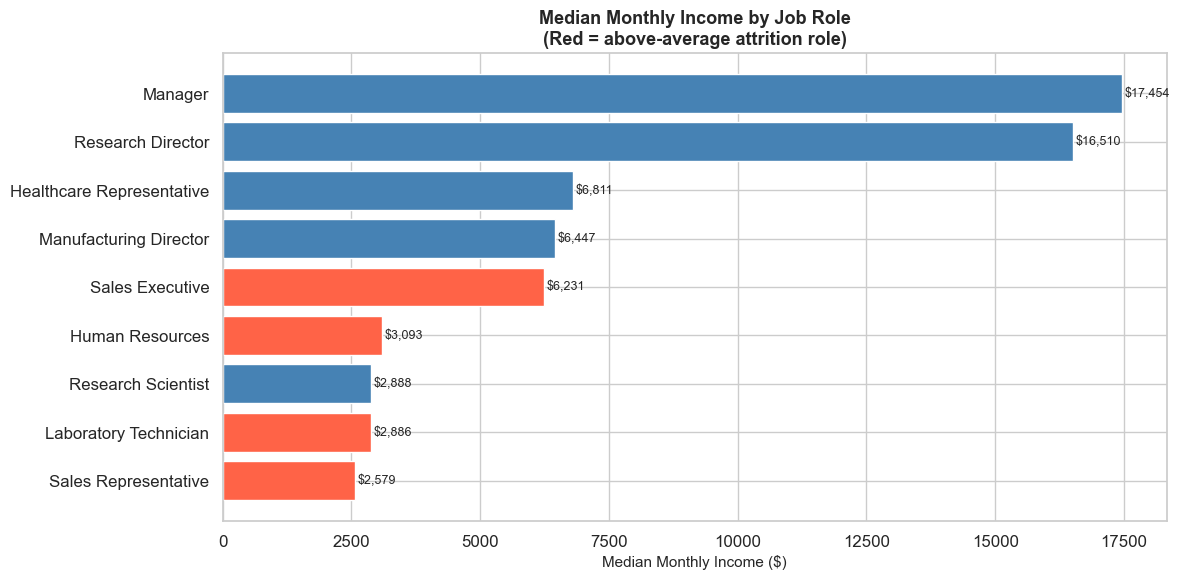

In [43]:
# Monthly income by job role
role_income = df.groupby('JobRole')['MonthlyIncome'].median().sort_values(ascending=True)
high_attrition_roles = jobrole_rate[jobrole_rate > overall_rate].index.tolist()

fig, ax = plt.subplots(figsize=(12, 6))
colors_role = ['tomato' if role in high_attrition_roles else 'steelblue'
               for role in role_income.index]
ax.barh(role_income.index, role_income.values, color=colors_role, edgecolor='white')
ax.set_xlabel('Median Monthly Income ($)')
ax.set_title('Median Monthly Income by Job Role\n(Red = above-average attrition role)', fontweight='bold')
for i, val in enumerate(role_income.values):
    ax.text(val + 50, i, f'${val:,.0f}', va='center', fontsize=9)
plt.tight_layout()
plt.show()


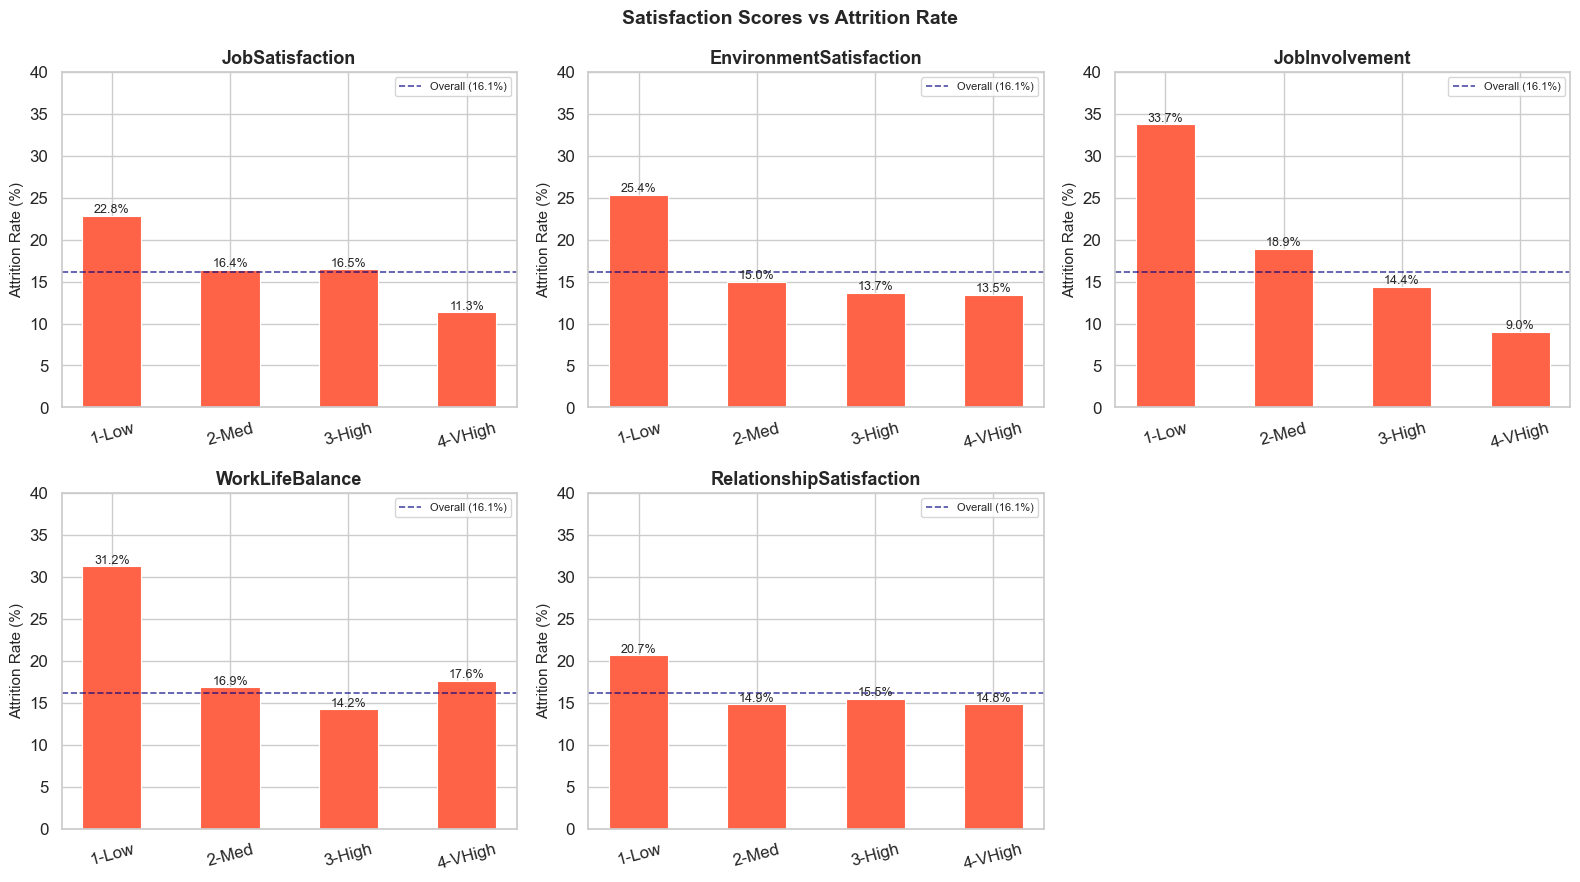

In [44]:
# Cell 10 — Satisfaction Scores Analysis
satisfaction_cols = ['JobSatisfaction', 'EnvironmentSatisfaction',
                     'JobInvolvement', 'WorkLifeBalance', 'RelationshipSatisfaction']

score_labels = {1: '1-Low', 2: '2-Med', 3: '3-High', 4: '4-VHigh'}

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for i, col in enumerate(satisfaction_cols):
    rate = df.groupby(col)['Attrition'].apply(
        lambda x: (x == 'Yes').mean() * 100).reset_index()
    rate.columns = [col, 'AttritionRate']
    rate[col] = rate[col].map(score_labels)

    bars = axes[i].bar(rate[col], rate['AttritionRate'],
                       color='tomato', edgecolor='white', linewidth=0.8, width=0.5)
    axes[i].axhline(y=overall_rate, color='navy', linestyle='--', linewidth=1.2,
                    label=f'Overall ({overall_rate:.1f}%)', alpha=0.7)
    axes[i].set_title(col, fontweight='bold')
    axes[i].set_ylabel('Attrition Rate (%)')
    axes[i].set_ylim(0, 40)
    axes[i].tick_params(axis='x', rotation=15)
    for bar, val in zip(bars, rate['AttritionRate']):
        axes[i].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
                     f'{val:.1f}%', ha='center', fontsize=9)
    axes[i].legend(fontsize=8)

axes[5].set_visible(False)

plt.suptitle('Satisfaction Scores vs Attrition Rate', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


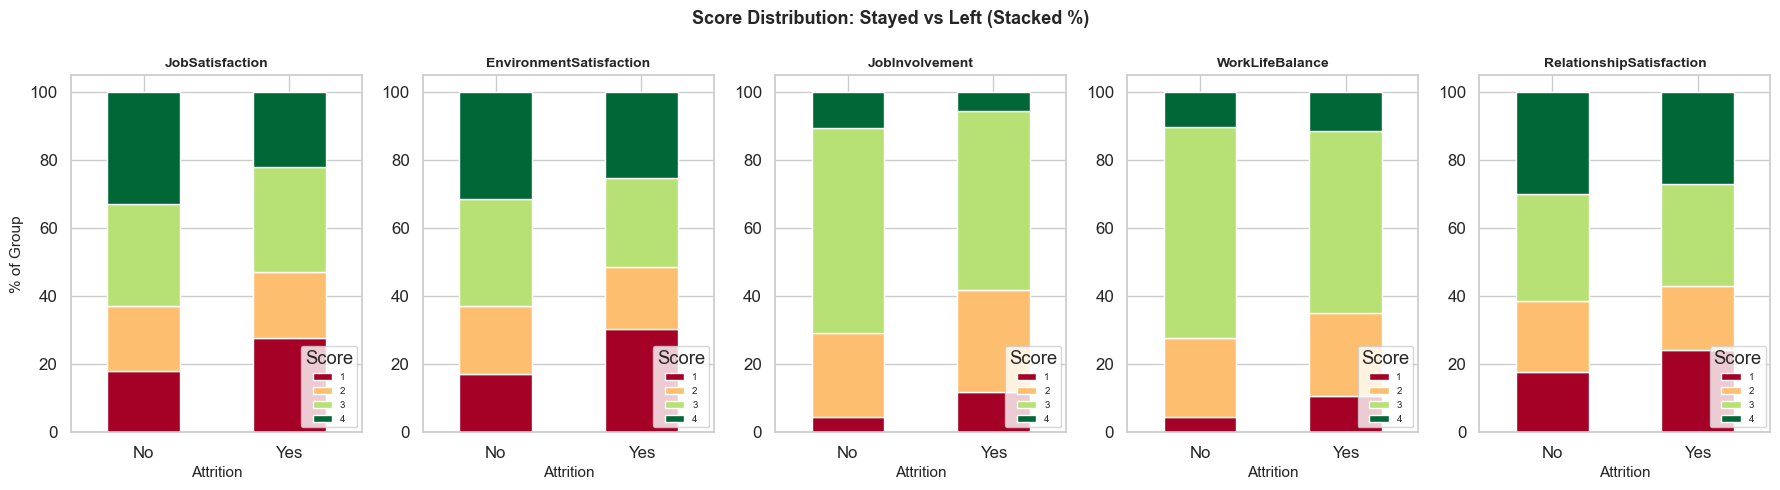

In [45]:
# Score distribution: stayed vs left (stacked %)
fig, axes = plt.subplots(1, len(satisfaction_cols), figsize=(18, 5))

for i, col in enumerate(satisfaction_cols):
    cross = pd.crosstab(df['Attrition'], df[col], normalize='index') * 100
    cross.plot(kind='bar', stacked=True, ax=axes[i],
               colormap='RdYlGn', edgecolor='white')
    axes[i].set_title(col, fontsize=10, fontweight='bold')
    axes[i].set_xlabel('Attrition')
    axes[i].set_ylabel('% of Group' if i == 0 else '')
    axes[i].tick_params(axis='x', rotation=0)
    axes[i].legend(title='Score', fontsize=7, loc='lower right')

plt.suptitle('Score Distribution: Stayed vs Left (Stacked %)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


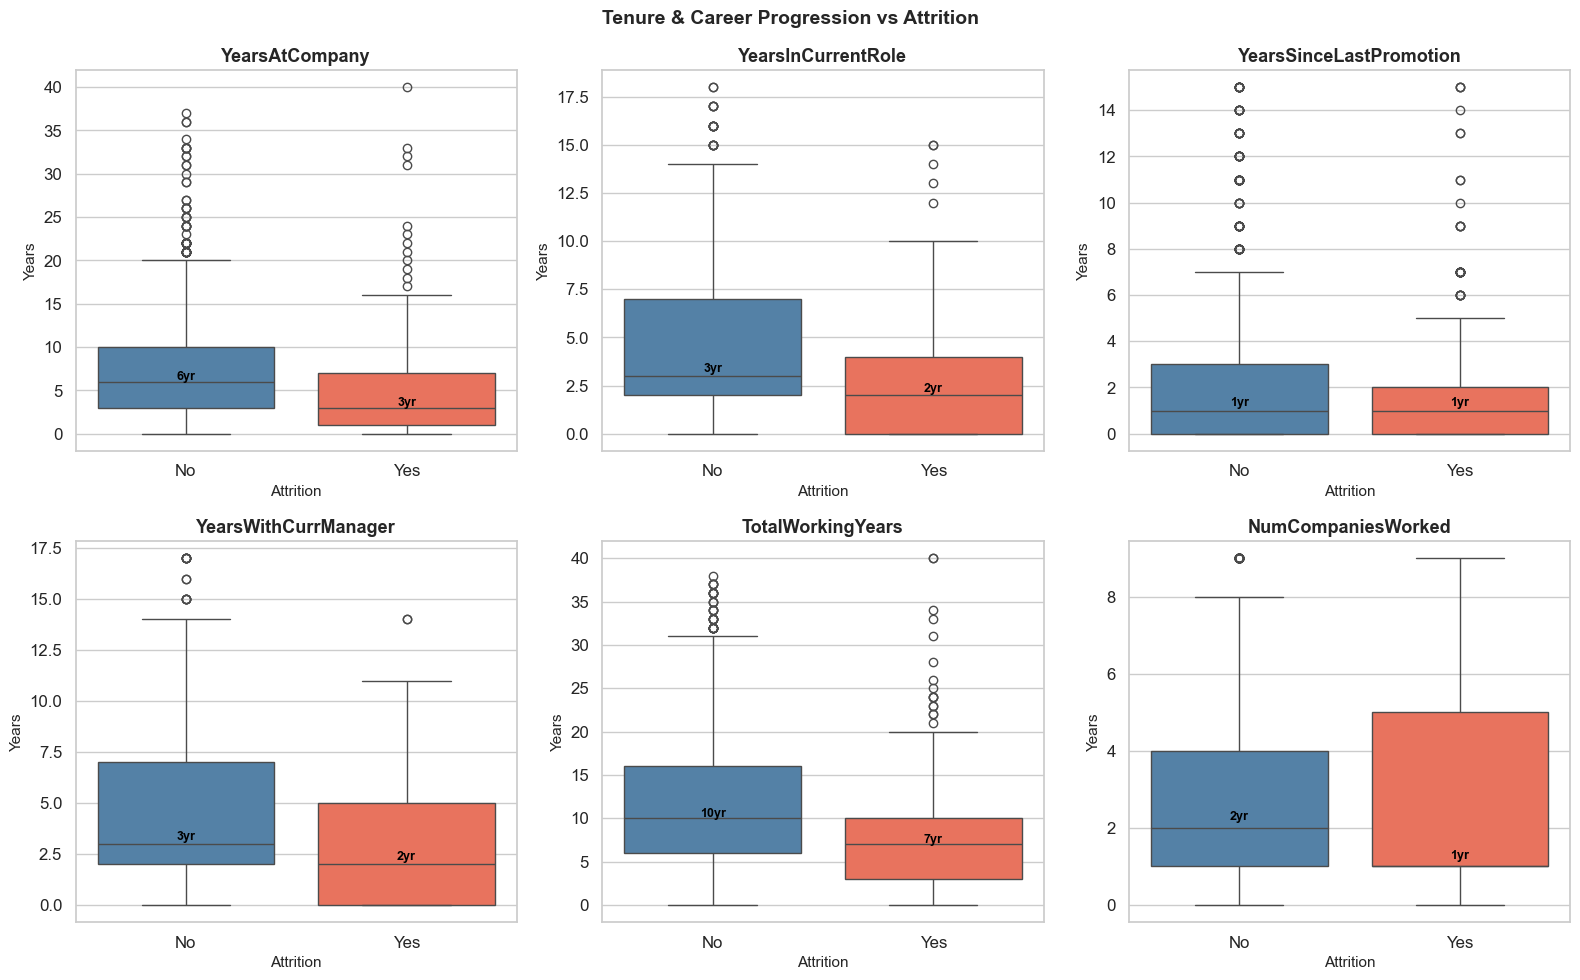

In [46]:
# Cell 11 — Tenure & Career Progression
tenure_cols = ['YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion',
               'YearsWithCurrManager', 'TotalWorkingYears', 'NumCompaniesWorked']

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(tenure_cols):
    sns.boxplot(data=df, x='Attrition', y=col, ax=axes[i],
                palette={'Yes': 'tomato', 'No': 'steelblue'}, order=['No', 'Yes'])
    axes[i].set_title(col, fontweight='bold')
    axes[i].set_xlabel('Attrition')
    axes[i].set_ylabel('Years')
    for j, group in enumerate(['No', 'Yes']):
        med = df[df['Attrition'] == group][col].median()
        axes[i].text(j, med + 0.2, f'{med:.0f}yr', ha='center', fontsize=9,
                     color='black', fontweight='bold')

plt.suptitle('Tenure & Career Progression vs Attrition', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


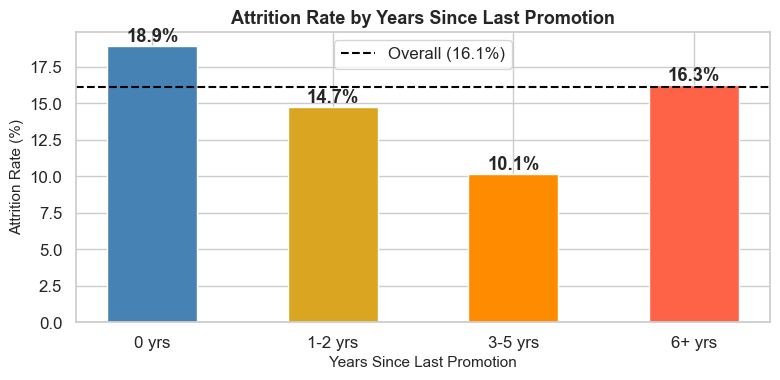

In [47]:
# Binned promotion stagnation analysis
df['PromoBucket'] = pd.cut(df['YearsSinceLastPromotion'],
                           bins=[-1, 0, 2, 5, 100],
                           labels=['0 yrs', '1-2 yrs', '3-5 yrs', '6+ yrs'])

promo_rate = df.groupby('PromoBucket', observed=True)['Attrition'].apply(
    lambda x: (x == 'Yes').mean() * 100)

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(promo_rate.index.astype(str), promo_rate.values,
       color=['steelblue', 'goldenrod', 'darkorange', 'tomato'],
       edgecolor='white', width=0.5)
ax.axhline(y=overall_rate, color='black', linestyle='--',
           label=f'Overall ({overall_rate:.1f}%)')
ax.set_title('Attrition Rate by Years Since Last Promotion', fontweight='bold')
ax.set_ylabel('Attrition Rate (%)')
ax.set_xlabel('Years Since Last Promotion')
for i, val in enumerate(promo_rate.values):
    ax.text(i, val + 0.3, f'{val:.1f}%', ha='center', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

df.drop(columns='PromoBucket', inplace=True)


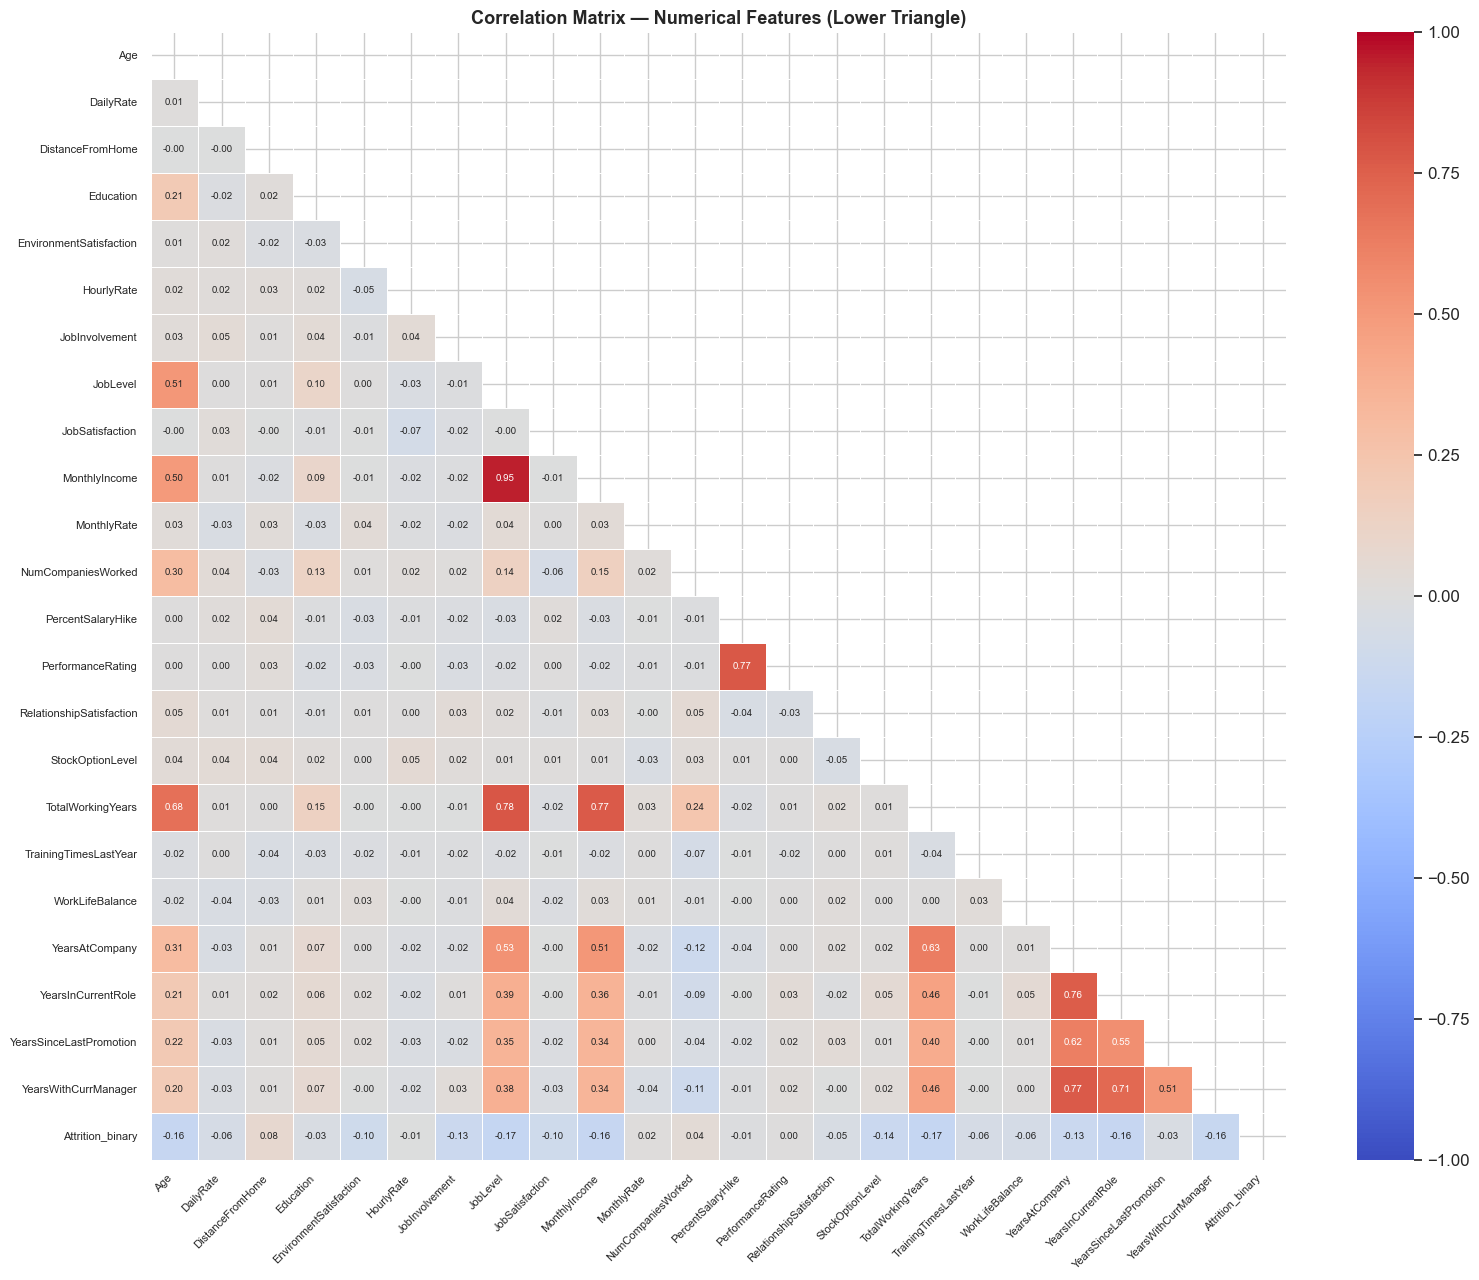

In [48]:
# Cell 12 — Correlation Heatmap
df_corr = df.copy()
df_corr['Attrition_binary'] = (df_corr['Attrition'] == 'Yes').astype(int)
df_corr.drop(columns=['Attrition'], inplace=True)

# Drop remaining categorical columns for pure numeric correlation
num_df = df_corr.select_dtypes(include=['int64', 'float64'])
corr_matrix = num_df.corr()

fig, ax = plt.subplots(figsize=(16, 13))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='coolwarm', center=0, vmin=-1, vmax=1,
            linewidths=0.4, linecolor='white',
            annot_kws={'size': 7}, ax=ax)
ax.set_title('Correlation Matrix — Numerical Features (Lower Triangle)', fontsize=13, fontweight='bold')
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(fontsize=8)
plt.tight_layout()
plt.show()


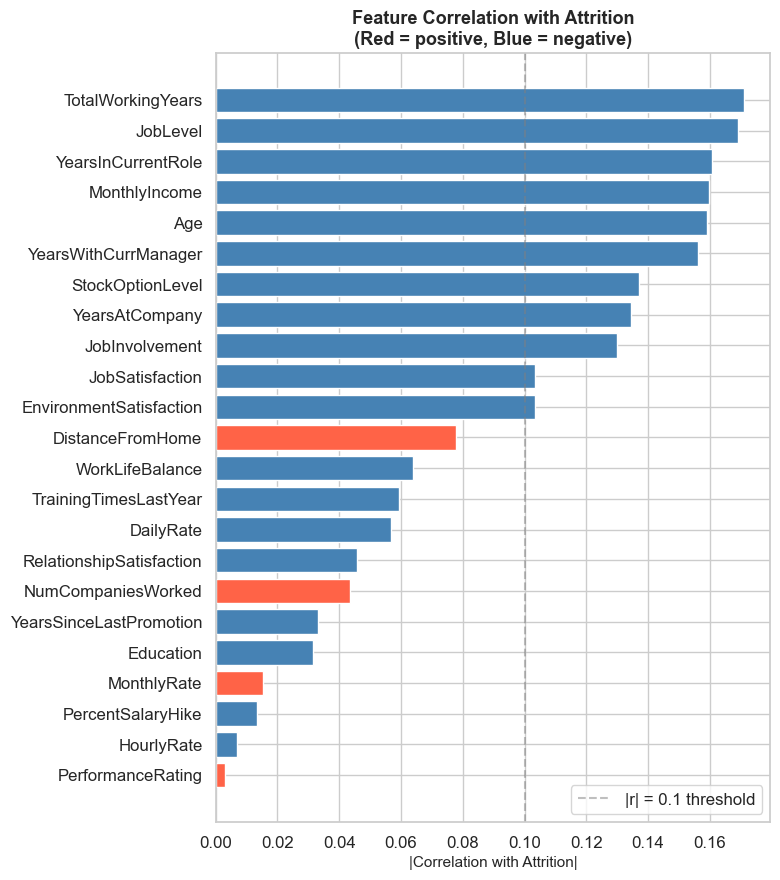

In [49]:
# Feature correlations with Attrition (sorted by absolute value)
attrition_corr = corr_matrix['Attrition_binary'].drop('Attrition_binary')
attrition_corr_sorted = attrition_corr.abs().sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 9))
colors = ['tomato' if attrition_corr[col] > 0 else 'steelblue'
          for col in attrition_corr_sorted.index]
ax.barh(attrition_corr_sorted.index, attrition_corr_sorted.values,
        color=colors, edgecolor='white')
ax.set_xlabel('|Correlation with Attrition|')
ax.set_title('Feature Correlation with Attrition\n(Red = positive, Blue = negative)',
             fontweight='bold')
ax.axvline(x=0.1, color='gray', linestyle='--', alpha=0.5, label='|r| = 0.1 threshold')
ax.legend()
plt.tight_layout()
plt.show()


## Key EDA Findings — IBM HR Attrition Dataset

### Dataset
- 1,470 employees, 35 original columns → 31 after dropping constants (`EmployeeCount`, `EmployeeNumber`, `Over18`, `StandardHours`)
- No missing values or duplicates
- Target: **Attrition = Yes (~16%)** vs **No (~84%)** — imbalanced ~5.2:1

### Top Attrition Drivers

| Factor | Observation |
|--------|-------------|
| **OverTime** | Employees doing overtime leave at ~30% vs ~10% — strongest single signal |
| **JobRole** | Sales Representatives and Lab Technicians have highest rates |
| **MaritalStatus** | Single employees leave at ~25%, vs ~12% Married |
| **BusinessTravel** | Frequent travelers leave at ~25%, Non-Travel at ~8% |
| **MonthlyIncome** | Median income of leavers is significantly lower |
| **JobInvolvement** | Score=1 (Low) employees leave at ~33% |
| **WorkLifeBalance** | Score=1 (Low) employees leave at ~31% |
| **YearsAtCompany** | Leavers have shorter median tenure — early attrition is dominant |
| **YearsSinceLastPromotion** | Non-linear: both 0 yrs and 6+ yrs show elevated rates |

### Multicollinearity Flags (for modeling)
- `YearsAtCompany`, `TotalWorkingYears`, `YearsInCurrentRole`, `YearsWithCurrManager` are highly intercorrelated
- `MonthlyIncome` is strongly correlated with `JobLevel` and `TotalWorkingYears`
- Consider feature selection or PCA before training

### Modeling Implications
- **Do not use accuracy** — 84% achievable by predicting "No" always
- **Priority metrics:** Recall (Yes), F1 (Yes), ROC-AUC, PR-AUC
- **Class imbalance handling:** SMOTE, `class_weight='balanced'`, or threshold tuning
- **High-signal features:** `OverTime`, `MonthlyIncome`, `JobRole`, `JobInvolvement`, `MaritalStatus`, `YearsAtCompany`, `WorkLifeBalance`, `BusinessTravel`


## Phase 2 — Preprocessing

In [50]:
# Cell B — Encode target variable
df['Attrition'] = df['Attrition'].map({'Yes': 1, 'No': 0})

X = df.drop(columns=['Attrition'])
y = df['Attrition']

print(f'X shape: {X.shape}')
print(f'y shape: {y.shape}')
print(f'Attrition rate: {y.mean():.1%}')

X shape: (1470, 30)
y shape: (1470,)
Attrition rate: 16.1%


In [51]:
# Cell C — Encode binary categoricals
X['Gender'] = X['Gender'].map({'Female': 0, 'Male': 1})
X['OverTime'] = X['OverTime'].map({'No': 0, 'Yes': 1})

print('Gender and OverTime encoded.')
print(X[['Gender', 'OverTime']].value_counts().sort_index())

Gender and OverTime encoded.
Gender  OverTime
0       0           408
        1           180
1       0           646
        1           236
Name: count, dtype: int64


In [52]:
# Cell D — Ordinal encode BusinessTravel (preserves travel frequency ordering)
travel_order = {'Non-Travel': 0, 'Travel_Rarely': 1, 'Travel_Frequently': 2}
X['BusinessTravel'] = X['BusinessTravel'].map(travel_order)

print('BusinessTravel encoded:', travel_order)
print(X['BusinessTravel'].value_counts().sort_index())

BusinessTravel encoded: {'Non-Travel': 0, 'Travel_Rarely': 1, 'Travel_Frequently': 2}
BusinessTravel
0     150
1    1043
2     277
Name: count, dtype: int64


In [ ]:
# Cell E — One-hot encode nominal categoricals (drop_first avoids dummy trap)
nominal_cols = ['Department', 'EducationField', 'JobRole', 'MaritalStatus']
X = pd.get_dummies(X, columns=nominal_cols, drop_first=True)

print(f'Shape after one-hot encoding: {X.shape}')
print(f'New dummy columns: {[c for c in X.columns if any(c.startswith(n + "_") for n in nominal_cols)]}')

Shape after one-hot encoding: (1470, 43)
New dummy columns: ['Department_Research & Development', 'Department_Sales', 'EducationField_Life Sciences', 'EducationField_Marketing', 'EducationField_Medical', 'EducationField_Other', 'EducationField_Technical Degree', 'JobRole_Human Resources', 'JobRole_Laboratory Technician', 'JobRole_Manager', 'JobRole_Manufacturing Director', 'JobRole_Research Director', 'JobRole_Research Scientist', 'JobRole_Sales Executive', 'JobRole_Sales Representative', 'MaritalStatus_Married', 'MaritalStatus_Single']


In [54]:
# Cell F — Train/test split (stratified to preserve 16%/84% class ratio)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Train: {X_train.shape}  |  Test: {X_test.shape}')
print(f'Attrition rate — train: {y_train.mean():.1%}  |  test: {y_test.mean():.1%}')

Train: (1176, 43)  |  Test: (294, 43)
Attrition rate — train: 16.2%  |  test: 16.0%


In [55]:
# Cell G — Scale all numeric features (fit on train only, apply to both)
numeric_cols = X_train.select_dtypes(include=['int64', 'float64', 'uint8']).columns.tolist()

scaler = StandardScaler()
X_train[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_test[numeric_cols] = scaler.transform(X_test[numeric_cols])

print(f'Scaled {len(numeric_cols)} numeric columns.')
print(f'X_train dtypes:\n{X_train.dtypes.value_counts()}')

Scaled 26 numeric columns.
X_train dtypes:
float64    26
bool       17
Name: count, dtype: int64


In [56]:
# Cell H — Preprocessing summary
print('=== PREPROCESSING COMPLETE ===')
print(f'\nFeatures:       {X_train.shape[1]}')
print(f'Train samples:  {X_train.shape[0]}  (attrition: {y_train.mean():.1%})')
print(f'Test  samples:  {X_test.shape[0]}  (attrition: {y_test.mean():.1%})')
print(f'\nNaN in X_train: {X_train.isnull().sum().sum()}')
print(f'NaN in X_test:  {X_test.isnull().sum().sum()}')
print(f'\nAll numeric:    {(X_train.dtypes != object).all()}')

=== PREPROCESSING COMPLETE ===

Features:       43
Train samples:  1176  (attrition: 16.2%)
Test  samples:  294  (attrition: 16.0%)

NaN in X_train: 0
NaN in X_test:  0

All numeric:    True
